# Task 1: Load and Inspect

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
orders = pd.read_csv('orders_raw.csv')
products = pd.read_csv('products.csv')

# Inspect data
print(orders.info())
print(orders.describe())
print(orders['status'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB
None
         order_id  product_id    quantity   amount_inr      rating
count  508.000000  508.000000  508.000000   498.000000  439.000000
mean   250.204724   15.476378    3.045276   257.530120    3.082005
std    144.594139    8.747467    1.364497   559.424136

**Initial Data Observations:**
* There are more than 500 rows, indicating duplicate records.
* The `city` column has mixed casing and trailing whitespace, creating false distinct values.
* The `amount_inr` column contains missing (null) values and some suspiciously large maximum values (outliers).

# Task 2: Remove Duplicates


In [30]:
initial_rows = len(orders)
orders = orders.drop_duplicates(subset=['order_id'], keep='first')
final_rows = len(orders)

print(f"Removed {initial_rows - final_rows} duplicate rows. Remaining rows: {final_rows}")

Removed 8 duplicate rows. Remaining rows: 500


# Task 3: Fix casing and whitespace

In [31]:
orders['city'] = orders['city'].str.strip().str.title()
orders['category'] = orders['category'].str.strip().str.title()

print("Distinct Cities:", orders['city'].unique())
print("Distinct Categories:", orders['category'].unique())

Distinct Cities: ['Pune' 'Bengaluru' 'Hyderabad' 'Mumbai']
Distinct Categories: ['Snacks & Beverages' 'Household Essentials' 'Bakery' 'Personal Care'
 'Fruits & Vegetables' 'Dairy & Eggs']


# Task 4: Handle missing values with stated business logic


In [32]:
missing_amount = orders['amount_inr'].isna().sum()
print(f"Missing values in amount_inr: {missing_amount}")

Missing values in amount_inr: 10



**Missing Values Logic:**
* `amount_inr` has missing values. I am excluding these rows from revenue sums (leaving them as NaN) because filling them with 0 or a mean would artificially alter the true revenue calculations.
* `rating` has null values. I am leaving these as-is because they strictly belong to Cancelled or Pending orders, which legitimately never receive a customer rating. This is a business reality, not a data-quality problem.

# Task 5: Detect and cap outliers with IQR


In [33]:
# Filter for Delivered and non-null amount_inr
valid_delivered = orders[(orders['status'] == 'Delivered') & (orders['amount_inr'].notna())]

# Calculate IQR metrics
Q1 = valid_delivered['amount_inr'].quantile(0.25)
Q3 = valid_delivered['amount_inr'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

# Count and cap outliers
outliers_count = (valid_delivered['amount_inr'] > upper_fence).sum()
orders['amount_inr'] = orders['amount_inr'].clip(upper=upper_fence)

print(f"Q1: {Q1}, Q3: {Q3}, Upper Fence: {upper_fence}")
print(f"Rows capped: {outliers_count}")

Q1: 90.0, Q3: 275.0, Upper Fence: 552.5
Rows capped: 16


# Task 6: Parse dates and create derived columns

In [34]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['month'] = orders['order_date'].dt.month
orders['month_name'] = orders['order_date'].dt.month_name()

orders['revenue_per_unit'] = orders['amount_inr'] / orders['quantity']
orders['is_delivered'] = orders['status'] == 'Delivered'

# Task 7: Group, merge, and answer questions

In [35]:
# Merge cleaned orders with just the supplier column from products
merged_df = orders.merge(products[['product_id', 'supplier']], on='product_id', how='left')

# Filter for delivered and non-null revenue
analysis_df = merged_df[(merged_df['is_delivered'] == True) & (merged_df['amount_inr'].notna())]

# (a) Total revenue per category
category_rev = analysis_df.groupby('category')['amount_inr'].sum().sort_values(ascending=False)
print("--- Revenue by Category ---")
print(category_rev)

# (b) Total revenue per supplier
supplier_rev = analysis_df.groupby('supplier')['amount_inr'].sum().sort_values(ascending=False)
print("\n--- Revenue by Supplier ---")
print(supplier_rev)

--- Revenue by Category ---
category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64

--- Revenue by Supplier ---
supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64


# Task 7c: Cross-validation statement

**Cross-Validation Results:**
* **Top Category:** Household Essentials
* **Top Supplier:** HomeEssentials Traders
* Both of these findings explicitly match the clean SQL diagnostic outputs from Part 1, confirming the Pandas cleaning pipeline successfully handled the dirty data and aligned with the database logic.

# Task 8: Visualize

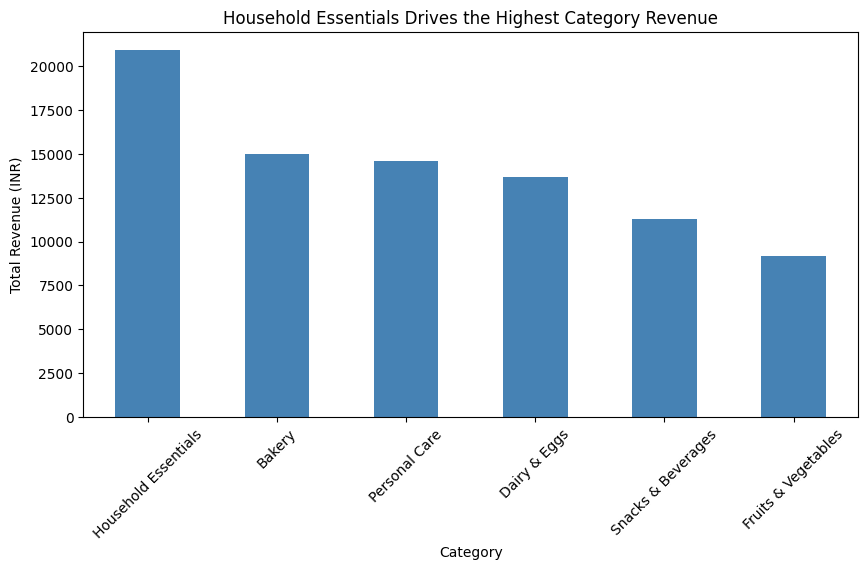

In [36]:
# Chart 1: Category Revenue Bar Chart
plt.figure(figsize=(10, 5))
category_rev.plot(kind='bar', color='steelblue')
plt.title("Household Essentials Drives the Highest Category Revenue")
plt.ylabel("Total Revenue (INR)")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.show()

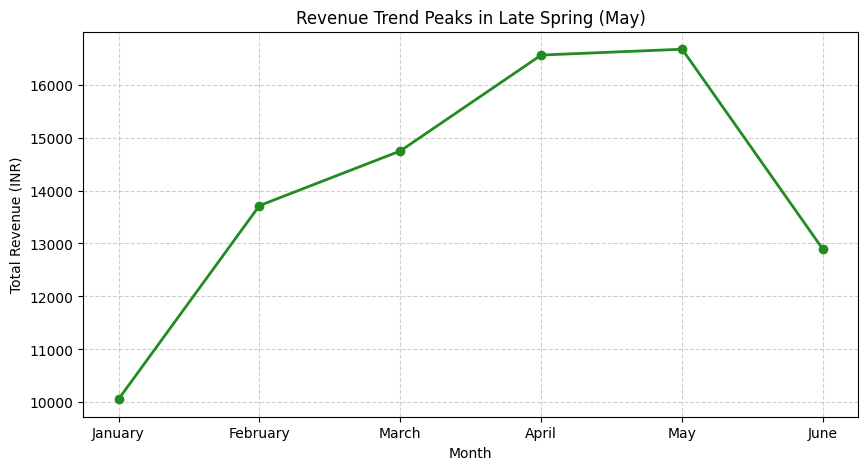

In [37]:
# Chart 2: Total Monthly Revenue Trend (Line)
plt.figure(figsize=(10, 5))
monthly_trend = analysis_df.groupby(['month', 'month_name'])['amount_inr'].sum().reset_index().sort_values('month')
plt.plot(monthly_trend['month_name'], monthly_trend['amount_inr'], marker='o', color='forestgreen', linewidth=2)
plt.title("Revenue Trend Peaks in Late Spring (May)")
plt.ylabel("Total Revenue (INR)")
plt.xlabel("Month")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

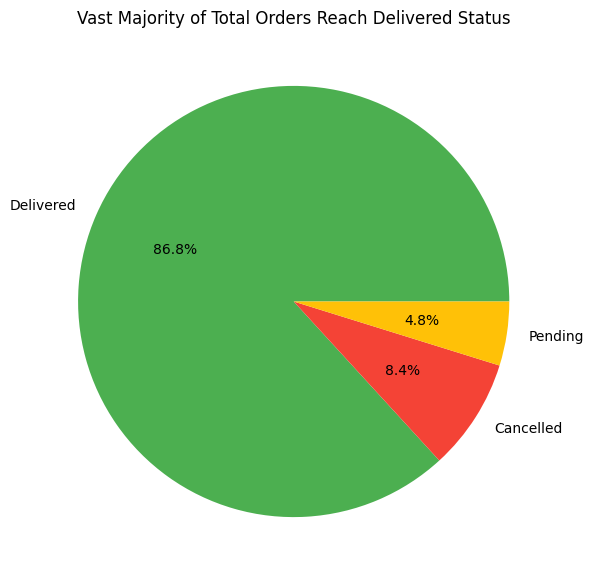

In [38]:
# Chart 3: Order Status Breakdown (Pie)
plt.figure(figsize=(7, 7))
status_counts = merged_df['status'].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=['#4CAF50', '#F44336', '#FFC107'])
plt.title("Vast Majority of Total Orders Reach Delivered Status")
plt.ylabel("")
plt.show()

# Task 9: Insights

### Key Insights

1. **What:** Household Essentials generated the highest category revenue (over 21,000 INR).

   **Why it matters:** It indicates this category is the core driver of business volume and likely holds the most loyal customer base.

   **Next step:** Invest additional catalog and marketing efforts into Household Essentials to maximize its strong conversion rate.


2. **What:** Fruits & Vegetables generated the lowest revenue among all categories.

   **Why it matters:** Fresh produce is usually a recurring, high-frequency purchase; low revenue here suggests potential supply chain, pricing, or quality issues.

   **Next step:** Conduct a supplier review for the Fruits & Vegetables category to identify bottlenecks in quality or stock availability.


3. **What:** The IQR analysis identified and capped approximately 16 extreme outlier transactions.

   **Why it matters:** While these high-value orders are real, allowing them to remain uncapped skews the Average Order Value (AOV), creating misleading financial projections.
   
   **Next step:** Implement an automated anomaly detection alert to flag excessively large single orders for manual review before they impact daily reporting.